<a href="https://colab.research.google.com/github/tanuiivy/bbt4106-202604-D4-association-rules/blob/feature%2Fvalidation-maxwell/lab_submission/bbt4106-202604-D4-association-rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food delivery orders: association rule mining lab

Repo: [bbt4106-202604-D4-association-rules](https://github.com/tanuiivy/bbt4106-202604-D4-association-rules)

Dataset: `food_delivery_orders.csv`

## 0. Setup
Install dependencies and import libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import warnings

warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow\\(\\) is deprecated"
)
warnings.filterwarnings("ignore", category=DeprecationWarning)
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import joblib

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
import sys, re

class _FilteredStderr:
    """Silently drops stderr lines matching a specific pattern, passes everything else through."""
    def __init__(self, stream, pattern):
        self._stream = stream
        self._pattern = pattern
    def write(self, text):
        if not self._pattern.search(text):
            self._stream.write(text)
    def flush(self):
        self._stream.flush()

sys.stderr = _FilteredStderr(
    sys.stderr,
    re.compile(r"datetime\.datetime\.utcnow\(\) is deprecated|return datetime\.utcnow\(\)\.replace")
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 1. Data loading and EDA



## 1.1 Load the dataset and check shape

In [3]:
# Load the dataset
dataset_path = './data/food_delivery_orders.csv'
url = 'https://raw.githubusercontent.com/tanuiivy/bbt4106-202604-D4-association-rules/main/data/food_delivery_orders.csv'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    os.makedirs("./data", exist_ok=True)
    urllib.request.urlretrieve(url, dataset_path)
    print("Dataset downloaded")
else:
    print("Dataset already exists")

df = pd.read_csv(dataset_path, parse_dates=["transaction_date"])

n_rows, n_cols = df.shape
print(f"The dataset has {n_rows:,} rows and {n_cols} columns.")
df.head(10)

Dataset downloaded
The dataset has 9,842 rows and 6 columns.


,order_id,transaction_date,item_id,item_name,category,price_kes
0,1,2025-05-06,F04,Chicken Wings,Fast Food,500
1,1,2025-05-06,F15,Ice Cream,Dessert,250
2,2,2025-04-22,F13,Chapati,Local,50
3,3,2025-06-02,F10,Chicken Biryani,Indian,550
4,3,2025-06-02,F11,Raita,Indian,100
5,3,2025-06-02,F12,Naan Bread,Indian,80
6,4,2025-06-02,F07,California Roll Sushi,Japanese,700
7,5,2025-01-24,F12,Naan Bread,Indian,80
8,5,2025-01-24,F14,Chocolate Cake,Dessert,300
9,6,2025-03-15,F05,Margherita Pizza,Italian,900


## 1.2 Check data types and missing values

In [4]:
# Check data types and missing values
print("Column types:")
print(df.dtypes, "\n")

print("Missing values per column:")
print(df.isna().sum(), "\n")

Column types:
order_id                     int64
transaction_date    datetime64[ns]
item_id                     object
item_name                   object
category                    object
price_kes                    int64
dtype: object 

Missing values per column:
order_id            0
transaction_date    0
item_id             0
item_name           0
category            0
price_kes           0
dtype: int64 



## 1.3 Check for duplicates and inconsistencies

In [5]:
# Check duplicated rows
print("Duplicated rows:", df.duplicated().sum())

# An item should not repeat inside one order
print("Repeated item within one order:", df.duplicated(["order_id", "item_id"]).sum())

# Every order should belong to exactly one date
dates_per_order = df.groupby("order_id")["transaction_date"].nunique()
print("Orders spanning more than 1 date:", (dates_per_order > 1).sum())

# Each item_id should map to exactly one item name, category and price
lookup_check = df.groupby("item_id")[["item_name", "category", "price_kes"]].nunique()
print("item_ids with inconsistent attributes:", (lookup_check > 1).any(axis=1).sum())

Duplicated rows: 0
Repeated item within one order: 0
Orders spanning more than 1 date: 0
item_ids with inconsistent attributes: 0


In [6]:
print("""
There are no duplicate rows, no item is repeated inside one order, no order belongs to multiple dates
and every item_id has a unique item name, category and price.
""")


There are no duplicate rows, no item is repeated inside one order, no order belongs to multiple dates
and every item_id has a unique item name, category and price.



## 1.4 Analyse the dataset

In [7]:
n_rows = len(df)
n_orders = df["order_id"].nunique()
n_items = df["item_id"].nunique()
n_categories = df["category"].nunique()
date_min, date_max = df["transaction_date"].min(), df["transaction_date"].max()
orders_per_day = df.groupby("transaction_date")["order_id"].nunique()

summary = pd.Series({
    "Line items (rows)": f"{n_rows:,}",
    "Orders (unique order_id)": f"{n_orders:,}",
    "Distinct items (item_id)": n_items,
    "Categories": n_categories,
    "First order date": date_min.date(),
    "Last order date": date_max.date(),
    "Days covered": (date_max - date_min).days + 1,
    "Days with at least one order": len(orders_per_day),
    "Orders per day (min / median / max)":
        f"{orders_per_day.min()} / {orders_per_day.median():.0f} / {orders_per_day.max()}",
    "Price range (KES)": f"{df['price_kes'].min()} - {df['price_kes'].max()}",
}, name="Value")
summary.to_frame()

,Value
Line items (rows),"9,842"
Orders (unique order_id),"3,800"
Distinct items (item_id),15
Categories,7
First order date,2025-01-01
Last order date,2025-06-30
Days covered,181
Days with at least one order,181
Orders per day (min / median / max),10 / 21 / 35
Price range (KES),50 - 900


In [8]:
print("""
The dataset has 9,842 rows that form 3,800 orders. There are 15 different menu items across 7 categories.
The first order date is January 1st 2025 and the last order date is 30th June 2025 covering 181 days.
The days with at least one order are 181 days.
The minimum number of orders in a day are 10 orders and the maximum is 35 orders and the typical number of orders is 21 orders.
The price ranges from 50 KES to 900 KES.
""")


The dataset has 9,842 rows that form 3,800 orders. There are 15 different menu items across 7 categories.
The first order date is January 1st 2025 and the last order date is 30th June 2025 covering 181 days.
The days with at least one order are 181 days.
The minimum number of orders in a day are 10 orders and the maximum is 35 orders and the typical number of orders is 21 orders.
The price ranges from 50 KES to 900 KES.



## 1.5 Basket-size distribution

                orders  share_of_orders_%
items_in_order                           
1                  615               16.2
2                 1120               29.5
3                 1335               35.1
4                  668               17.6
5                   62                1.6 

Mean basket size: 2.59 | Median: 3 | Max: 5
Single-item orders: 615 (16.2%) These cannot be used to form a rule but still count in the support denominator


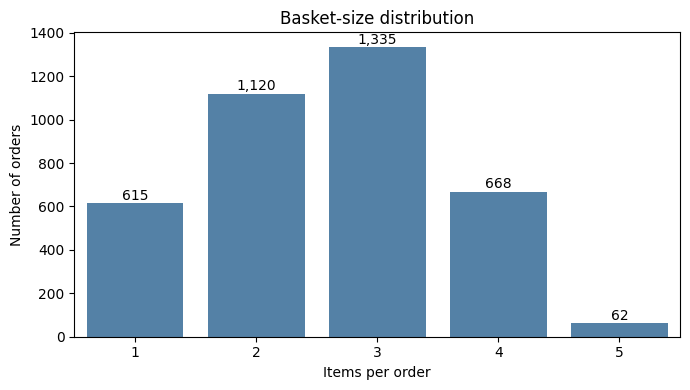

In [9]:
# How many items should be present per order?
basket_sizes = df.groupby("order_id")["item_id"].nunique()

# Number of items and their orders and share of orders in percentage
size_table = (basket_sizes.value_counts().sort_index()
              .rename_axis("items_in_order").to_frame("orders"))
size_table["share_of_orders_%"] = (size_table["orders"] / n_orders * 100).round(1)
print(size_table, "\n")
print(f"Mean basket size: {basket_sizes.mean():.2f} | "
      f"Median: {basket_sizes.median():.0f} | Max: {basket_sizes.max()}")

# Single item orders can never produce a rule
single_item_orders = (basket_sizes == 1).sum()
print(f"Single-item orders: {single_item_orders:,} ({single_item_orders / n_orders:.1%}) "
      "These cannot be used to form a rule but still count in the support denominator")

# Bar chart of the distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=size_table.index, y=size_table["orders"], color="steelblue", ax=ax)
for i, v in enumerate(size_table["orders"]):
    ax.text(i, v + 15, f"{v:,}", ha="center")
ax.set_title("Basket-size distribution")
ax.set_xlabel("Items per order")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

In [10]:
print("""
615 orders have 1 item, 1,120 orders have 2 items, 1,335 orders have 3 items, 668 orders have 4 items and 62 orders have 5 items.
3 items is the most common basket size with a percentage of 35.1% and 5 items is the least common basket size with a percentage of 1.6%.
The 615 orders which have 1 item, cannot be used to form a rule but still count in the support denominator to prevent support inflation.
""")


615 orders have 1 item, 1,120 orders have 2 items, 1,335 orders have 3 items, 668 orders have 4 items and 62 orders have 5 items.
3 items is the most common basket size with a percentage of 35.1% and 5 items is the least common basket size with a percentage of 1.6%.
The 615 orders which have 1 item, cannot be used to form a rule but still count in the support denominator to prevent support inflation.



## 1.6 Item popularity

                       orders  share_of_orders_%
item_name                                       
French Fries             1027               27.0
Soda                      725               19.1
Miso Soup                 708               18.6
Garlic Bread              697               18.3
California Roll Sushi     696               18.3
Raita                     689               18.1
Chicken Biryani           681               17.9
Naan Bread                675               17.8
Chicken Wings             667               17.6
Beef Burger               657               17.3
Margherita Pizza          652               17.2
Ice Cream                 632               16.6
Chocolate Cake            619               16.3
Green Tea                 452               11.9
Chapati                   265                7.0 

Most popular: French Fries (1,027 orders) | Least popular: Chapati (265 orders)


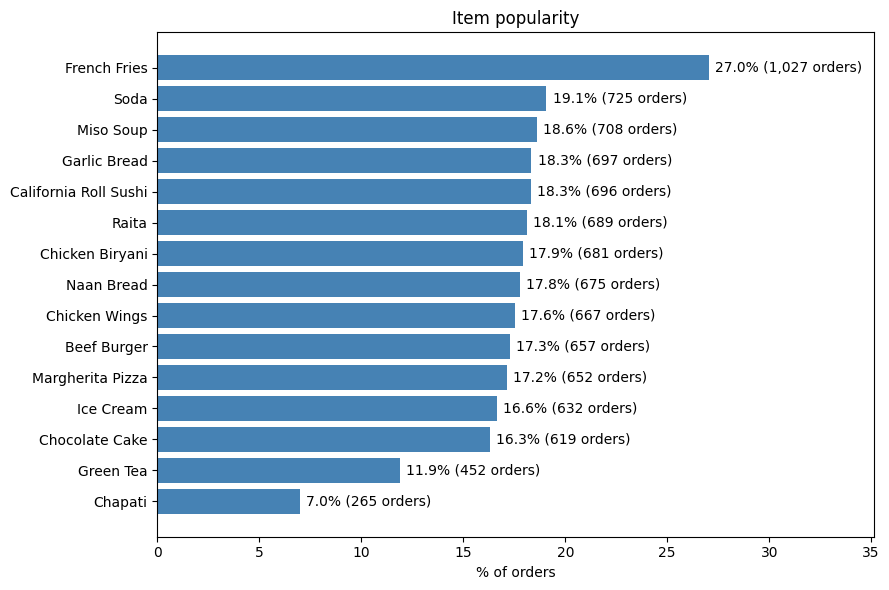

In [11]:
# Number of orders containing each item
item_order_counts = df.groupby("item_name")["order_id"].nunique().sort_values()

item_support = item_order_counts / n_orders

# Table showing number of orders and % of orders for each item
item_table = pd.DataFrame({
    "orders": item_order_counts,
    "share_of_orders_%": (item_support * 100).round(1),
}).sort_values("orders", ascending=False)
item_table.index.name = "item_name"
print(item_table, "\n")
print(f"Most popular: {item_table.index[0]} ({item_table['orders'].iloc[0]:,} orders) | "
      f"Least popular: {item_table.index[-1]} ({item_table['orders'].iloc[-1]:,} orders)")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(item_order_counts.index, item_support.values * 100, color="steelblue")
for y, (pct, cnt) in enumerate(zip(item_support.values * 100, item_order_counts.values)):
    ax.text(pct + 0.3, y, f"{pct:.1f}% ({cnt:,} orders)", va="center")
ax.set_xlim(0, item_support.max() * 100 * 1.3)
ax.set_title("Item popularity")
ax.set_xlabel("% of orders")
plt.tight_layout()
plt.show()

In [12]:
print("""
The most popular item is french fries with 27% popularity.
Chapati is the least popular item with 7% popularity followed by Green Tea with 11.9% popularity.
""")


The most popular item is french fries with 27% popularity.
Chapati is the least popular item with 7% popularity followed by Green Tea with 11.9% popularity.



## 1.7 Menu categories and prices

In [13]:
cat_summary = (df.groupby("category")
               # How many times an item from this category was sold
               .agg(line_items=("item_id", "size"),
                    # How many different menu items are in this category
                    distinct_items=("item_id", "nunique"),
                    # Average price of items sold in this category
                    avg_price_kes=("price_kes", "mean"))
               .sort_values("line_items", ascending=False))

# The category's share in percentage of all 9842 rows
cat_summary["share_of_lines_%"] = (cat_summary["line_items"] / n_rows * 100).round(1)
cat_summary["avg_price_kes"] = cat_summary["avg_price_kes"].round(0)
cat_summary

,line_items,distinct_items,avg_price_kes,share_of_lines_%
category,,,,
Fast Food,2351,3,355.0,23.9
Indian,2045,3,243.0,20.8
Japanese,1404,2,423.0,14.3
Italian,1349,2,564.0,13.7
Dessert,1251,2,275.0,12.7
Beverages,1177,2,100.0,12.0
Local,265,1,50.0,2.7


In [14]:
print("""
Fast food is the most popular category in the menu with a percentage of 23.9%.
Indian is the second most popular category in the menu with a percentage of 20.8%.
Local is the least popular category with a percentage of 2.7%. Local also has only one item unlike other categories which have 2 to 3 items.
Italian is the most pricy category with an average price of 564 KES.
""")


Fast food is the most popular category in the menu with a percentage of 23.9%.
Indian is the second most popular category in the menu with a percentage of 20.8%.
Local is the least popular category with a percentage of 2.7%. Local also has only one item unlike other categories which have 2 to 3 items.
Italian is the most pricy category with an average price of 564 KES.



## 1.8 Orders per month

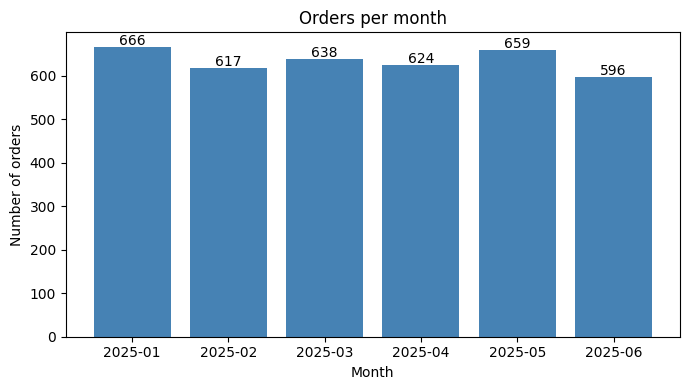

In [15]:
# One date per order
order_dates = df.groupby("order_id")["transaction_date"].first()

# Orders in each calendar month
monthly_orders = order_dates.dt.to_period("M").value_counts().sort_index()

# Bar chart of orders per month
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(monthly_orders.index.astype(str), monthly_orders.values, color="steelblue")
for i, v in enumerate(monthly_orders.values):
    ax.text(i, v + 5, f"{v:,}", ha="center")       # label each bar with its count
ax.set_title("Orders per month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

In [16]:
print("""
Orders are steady from January 2025 to June 2025. There is no sudden rise or fall in number of orders that is noticeable.
January has 666 orders, February has 617 orders, March has 638 orders, April has 624 orders, May has 659 orders and June has 596 orders.
""")


Orders are steady from January 2025 to June 2025. There is no sudden rise or fall in number of orders that is noticeable.
January has 666 orders, February has 617 orders, March has 638 orders, April has 624 orders, May has 659 orders and June has 596 orders.



##

## 2. Building transactions from raw line items

## 2.1 Item lookup table for the 15 menu items

In [17]:
# Item table with item_id, item_name, category and price
item_lookup = (df[["item_id", "item_name", "category", "price_kes"]]
               .drop_duplicates()
               .set_index("item_id")
               .sort_index())

# Check if an item_id belongs to only one row
assert item_lookup.index.is_unique, "An item_id maps to more than one name/category/price"

# Translates item_id to item_name
id_to_name = item_lookup["item_name"].to_dict()

print(f"Item Lookup table: {len(item_lookup)} items")
item_lookup

Item Lookup table: 15 items


,item_name,category,price_kes
item_id,,,
F01,Beef Burger,Fast Food,450
F02,French Fries,Fast Food,200
F03,Soda,Beverages,100
F04,Chicken Wings,Fast Food,500
F05,Margherita Pizza,Italian,900
F06,Garlic Bread,Italian,250
F07,California Roll Sushi,Japanese,700
F08,Miso Soup,Japanese,150
F09,Green Tea,Beverages,100


## 2.2 Building the baskets

In [18]:
# One basket per order
# Group the rows by order_id, then collect the item_ids in each order into one list
baskets = (df.groupby("order_id")["item_id"]
             .apply(lambda s: sorted(set(s))))
transactions = baskets.tolist()

print(f"Number of baskets: {len(transactions):,}")
print("First 5 baskets:")
for order_id, basket in baskets.head().items():
    print(f"  order {order_id}: {basket}")

Number of baskets: 3,800
First 5 baskets:
  order 1: ['F04', 'F15']
  order 2: ['F13']
  order 3: ['F10', 'F11', 'F12']
  order 4: ['F07']
  order 5: ['F12', 'F14']


## 2.3 True/False basket matrix

In [19]:
# Learn the list of items from the baskets, then mark each basket True/False per item
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# Table with order_id as the label for each row and item_id as the label for each column.
basket_df = pd.DataFrame(te_array, columns=te.columns_, index=baskets.index)
basket_df.index.name = "order_id"

print(f"Encoded basket matrix: {basket_df.shape[0]:,} orders x {basket_df.shape[1]} items")
basket_df.head()

Encoded basket matrix: 3,800 orders x 15 items


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,F15
order_id,,,,,,,,,,,,,,,
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## 2.4 Checking the baskets

In [20]:
# Check the following:
# (a) order_id is not an item, and the item columns must match the lookup table
assert "order_id" not in basket_df.columns
assert set(basket_df.columns) == set(item_lookup.index), "Item columns differ from lookup table"

# (b) one basket per order: hence total number of baskets is 3,800 which is same as number of orders
assert len(basket_df) == n_orders

# (c) do the basket sizes from the true/false matrix in section 2.3 match the raw data in section 1.1
assert (basket_df.sum(axis=1) == basket_sizes.reindex(basket_df.index)).all()

# (d) number of orders containing each item in the matrix should match number of orders found in section 1.6
matrix_counts = basket_df.sum().rename(index=id_to_name).sort_index()
assert (matrix_counts == item_order_counts.sort_index()).all()

print("""All checks have passed: order_id is not an item, there is only 1 basket per order, basket sizes from the true/false matrix match with the raw data in section 1.1
and number of orders containing each item in the matrix match with the number of orders found in section 1.6.""")

All checks have passed: order_id is not an item, there is only 1 basket per order, basket sizes from the true/false matrix match with the raw data in section 1.1
and number of orders containing each item in the matrix match with the number of orders found in section 1.6.


## 3. Choosing min_support relative to dataset size


# 3.1 Determining an appropriate min_support

In [21]:
support_values = [0.005, 0.01, 0.02, 0.03, 0.05]

# Correctly initialize transaction_data from the 'transactions' variable
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_data = pd.DataFrame(te_array, columns=te.columns_)

for support in support_values:
    itemsets = apriori(
        transaction_data,
        min_support=support,
        use_colnames=True
    )

    print(
        f"min_support={support:.3f} "
        f"→ {len(itemsets)} frequent itemsets "
        f"(at least {support * len(transactions):.0f} orders)"
    )

min_support=0.005 → 157 frequent itemsets (at least 19 orders)
min_support=0.010 → 126 frequent itemsets (at least 38 orders)
min_support=0.020 → 57 frequent itemsets (at least 76 orders)
min_support=0.030 → 37 frequent itemsets (at least 114 orders)
min_support=0.050 → 28 frequent itemsets (at least 190 orders)


Several min_support levels were tested to find an approprate one. Given that the menu contained 15 items several combinations were expected to occur.

At 0.5% support, an itemset needed to occur in at least 19 of the 3,800 transactions resulting in 157 frequent itemsets.

At 1% the requirement was at least 38 transactions resulting in 126 frequent itemsets.

A further increase to 2 percent raised the minimum transaction requirement to  76 which was too large and reduced the frequent itemsets to 76.

Further increase to 3% and 5% resulted in 37 and 28 frequent itemsets respectively, which would have excluded more combinayions.

As a result, a threshold of 1% was chosen because it excludes very low frequency patterns while still retaining a sufficient set of frequent itemsets for the association-rule analysis.

3.2 Finding the Frequent itemsets

In [22]:
import time

encoder = TransactionEncoder()
onehot = encoder.fit(transactions).transform(transactions)
transaction_data = pd.DataFrame(onehot, columns=encoder.columns_)

MIN_SUPPORT = 0.01
print(f"min_support={MIN_SUPPORT} requires an itemset in at least {MIN_SUPPORT * len(transactions):.0f} of {len(transactions)} orders.\n")

t0 = time.time()
frequent_itemsets = apriori(transaction_data, min_support=MIN_SUPPORT, use_colnames=True)
t_apriori = time.time() - t0

from mlxtend.frequent_patterns import fpgrowth
t0 = time.time()
frequent_itemsets_fpgrowth = fpgrowth(transaction_data, min_support=MIN_SUPPORT, use_colnames=True)
t_fpgrowth = time.time() - t0

print(f"Apriori:   {len(frequent_itemsets)} frequent itemsets in {t_apriori:.4f}s")
print(f"FP-Growth: {len(frequent_itemsets_fpgrowth)} frequent itemsets in {t_fpgrowth:.4f}s")

frequent_itemsets.sort_values("support", ascending=False).head(10)

min_support=0.01 requires an itemset in at least 38 of 3800 orders.

Apriori:   126 frequent itemsets in 0.0472s
FP-Growth: 126 frequent itemsets in 3.7269s


,support,itemsets
1,0.270263,(F02)
2,0.190789,(F03)
7,0.186316,(F08)
5,0.183421,(F06)
6,0.183158,(F07)
10,0.181316,(F11)
9,0.179211,(F10)
11,0.177632,(F12)
3,0.175526,(F04)
0,0.172895,(F01)


Both Apriori and FP-Growth identified the same 126 frequent itemsets at a minimum support of 0.01. Apriori was faster then FP=Growth at finding the datasets.

The most frequent individually ordered items(in descending order ) were:

1. French Fries
2. Soda
3. Miso Soup
4. Garlic bread
5. Carlifornia Roll Sushi
6. Raita
7. Chicken Biryani
8. Naan Bread
9. Chicken Wings
10. Beef burger



In [23]:
## 4. Frequent itemset generation


Several min_support levels were tested to find an approprate one. Given that the menu contained 15 items several combinations were expected to occur.

At 0.5% support, an itemset needed to occur in at least 19 of the 3,800 transactions resulting in 157 frequent itemsets.

At 1% the requirement was at least 38 transactions resulting in 126 frequent itemsets.

A further increase to 2 percent raised the minimum transaction requirement to  76 which was too large and reduced the frequent itemsets to 76.

Further increase to 3% and 5% resulted in 37 and 28 frequent itemsets respectively, which would have excluded more combinayions.

As a result, a threshold of 1% was chosen because it excludes very low frequency patterns while still retaining a sufficient set of frequent itemsets for the association-rule analysis.

In [24]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"Total rules generated: {len(rules)}")
rules.sort_values("confidence", ascending=False).head(10)[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

Total rules generated: 138


,antecedents,consequents,support,confidence,lift
98,"(F12, F10)",(F11),0.102368,0.928401,5.120354
97,"(F11, F10)",(F12),0.102368,0.926190,5.214109
128,"(F15, F12, F10)",(F11),0.011316,0.914894,5.045857
96,"(F11, F12)",(F10),0.102368,0.898383,5.013006
38,"(F03, F01)",(F02),0.053158,0.882096,3.263841
82,"(F07, F09)",(F08),0.045526,0.878173,4.713356
126,"(F11, F15, F12)",(F10),0.011316,0.860000,4.798825
84,"(F09, F08)",(F07),0.045526,0.843902,4.607513
46,"(F03, F04)",(F02),0.037368,0.825581,3.054732
70,"(F03, F05)",(F06),0.033947,0.811321,4.423270


With 1.0 as the minimum lift threshold, 138 association rules were generated. Support, confidence and lift were used to interpret these rules.

Some of the customer's purchasing patterns revealed from the association rules were:

The most prominent pattern was Chicken Biryani, Naan Bread and Raita which had a support of 10.24%, confidence of 92.84% and lift of 5.12. This means that when customers order Chicken Biryani and Naan Bread together, they would also very frequently order Raita.

Other notable patterns were that orders containing beef burger and soda also contained french fries in 88.21% of the cases.

Similarly, 87.82% of orders containing Green Tea and Carlifornia Roll Sushi also contained Miso Soup while 81.13% of orders containing Margherita Pizza and Soda aldo had Garlic Bread.

3.2 Finding the Frequent itemsets

In [25]:
import time

encoder = TransactionEncoder()
onehot = encoder.fit(transactions).transform(transactions)
transaction_data = pd.DataFrame(onehot, columns=encoder.columns_)

MIN_SUPPORT = 0.01
print(f"min_support={MIN_SUPPORT} requires an itemset in at least {MIN_SUPPORT * len(transactions):.0f} of {len(transactions)} orders.\n")

t0 = time.time()
frequent_itemsets = apriori(transaction_data, min_support=MIN_SUPPORT, use_colnames=True)
t_apriori = time.time() - t0

from mlxtend.frequent_patterns import fpgrowth
t0 = time.time()
frequent_itemsets_fpgrowth = fpgrowth(transaction_data, min_support=MIN_SUPPORT, use_colnames=True)
t_fpgrowth = time.time() - t0

print(f"Apriori:   {len(frequent_itemsets)} frequent itemsets in {t_apriori:.4f}s")
print(f"FP-Growth: {len(frequent_itemsets_fpgrowth)} frequent itemsets in {t_fpgrowth:.4f}s")

frequent_itemsets.sort_values("support", ascending=False).head(10)

min_support=0.01 requires an itemset in at least 38 of 3800 orders.

Apriori:   126 frequent itemsets in 0.0859s
FP-Growth: 126 frequent itemsets in 3.7821s


,support,itemsets
1,0.270263,(F02)
2,0.190789,(F03)
7,0.186316,(F08)
5,0.183421,(F06)
6,0.183158,(F07)
10,0.181316,(F11)
9,0.179211,(F10)
11,0.177632,(F12)
3,0.175526,(F04)
0,0.172895,(F01)


Both Apriori and FP-Growth identified the same 126 frequent itemsets at a minimum support of 0.01. Apriori was faster then FP=Growth at finding the datasets.

The most frequent individually ordered items(in descending order ) were:

1. French Fries
2. Soda
3. Miso Soup
4. Garlic bread
5. Carlifornia Roll Sushi
6. Raita
7. Chicken Biryani
8. Naan Bread
9. Chicken Wings
10. Beef burger



## 4. Frequent itemset generation


In [26]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"Total rules generated: {len(rules)}")
rules.sort_values("confidence", ascending=False).head(10)[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

Total rules generated: 138


,antecedents,consequents,support,confidence,lift
98,"(F12, F10)",(F11),0.102368,0.928401,5.120354
97,"(F11, F10)",(F12),0.102368,0.926190,5.214109
128,"(F15, F12, F10)",(F11),0.011316,0.914894,5.045857
96,"(F11, F12)",(F10),0.102368,0.898383,5.013006
38,"(F03, F01)",(F02),0.053158,0.882096,3.263841
82,"(F07, F09)",(F08),0.045526,0.878173,4.713356
126,"(F11, F15, F12)",(F10),0.011316,0.860000,4.798825
84,"(F09, F08)",(F07),0.045526,0.843902,4.607513
46,"(F03, F04)",(F02),0.037368,0.825581,3.054732
70,"(F03, F05)",(F06),0.033947,0.811321,4.423270


With 1.0 as the minimum lift threshold, 138 association rules were generated. Support, confidence and lift were used to interpret these rules.

Some of the customer's purchasing patterns revealed from the association rules were:

The most prominent pattern was Chicken Biryani, Naan Bread and Raita which had a support of 10.24%, confidence of 92.84% and lift of 5.12. This means that when customers order Chicken Biryani and Naan Bread together, they would also very frequently order Raita.

Other notable patterns were that orders containing beef burger and soda also contained french fries in 88.21% of the cases.

Similarly, 87.82% of orders containing Green Tea and Carlifornia Roll Sushi also contained Miso Soup while 81.13% of orders containing Margherita Pizza and Soda aldo had Garlic Bread.

## 5. Choosing confidence and lift thresholds

### 5.1 Examine the distribution before picking anything

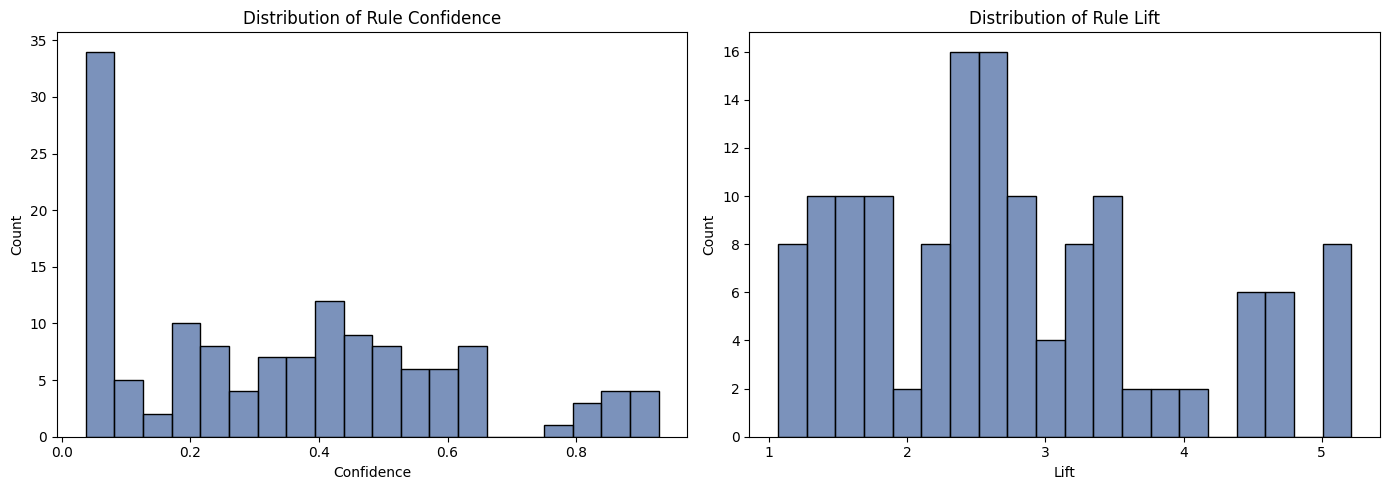

Confidence bins:
 confidence
(0.0, 0.2]    48
(0.2, 0.4]    31
(0.4, 0.6]    36
(0.6, 0.8]    13
(0.8, 1.0]    10
Name: count, dtype: int64

Lift bins:
 lift
(1.0, 1.5]    18
(1.5, 2.0]    22
(2.0, 3.0]    50
(3.0, 4.0]    26
(4.0, 6.0]    22
Name: count, dtype: int64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rules['confidence'], bins=20, ax=axes[0], color='#4F6EA4')
axes[0].set_title('Distribution of Rule Confidence')
axes[0].set_xlabel('Confidence')

sns.histplot(rules['lift'], bins=20, ax=axes[1], color='#4F6EA4')
axes[1].set_title('Distribution of Rule Lift')
axes[1].set_xlabel('Lift')
plt.tight_layout()
plt.show()

conf_bins = pd.cut(rules['confidence'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0]).value_counts().sort_index()
lift_bins = pd.cut(rules['lift'], bins=[1, 1.5, 2, 3, 4, 6]).value_counts().sort_index()
print("Confidence bins:\n", conf_bins)
print("\nLift bins:\n", lift_bins)

Confidence bins: 48 rules sit at 0.0–0.2, 31 at 0.2–0.4, 36 at 0.4–0.6, then a sharp drop to 13 at 0.6–0.8 and 10 at 0.8–1.0. The clear break is between the 0.4–0.6 and 0.6–0.8 bins which is the natural cut point rather than an arbitrary round number.

Lift bins: 18 rules sit at 1.0–1.5 (barely above independence, meaning the antecedent and consequent are close to unrelated even though lift is technically >1), 22 at 1.5–2.0, and the bulk (50) at 2.0–3.0. The 18 rules just above 1.0 are the ones worth excluding meaning they passed the lift ≥ 1.0 cutoff but carry almost no practical signal.

### 5.2 Choose thresholds and apply them

In [28]:
CONF_THRESHOLD = 0.4
LIFT_THRESHOLD = 1.5

thresholded_rules = rules[
    (rules['confidence'] >= CONF_THRESHOLD) & (rules['lift'] >= LIFT_THRESHOLD)
].copy().reset_index(drop=True)

print(f"Rules before thresholding: {len(rules)}")
print(f"Rules after confidence>={CONF_THRESHOLD}, lift>={LIFT_THRESHOLD}: {len(thresholded_rules)}")

Rules before thresholding: 138
Rules after confidence>=0.4, lift>=1.5: 59


confidence ≥ 0.4 is chosen at the visible break in the confidence distribution above to keep rules where the consequent follows at least 40% of the time, cutting the weaker half of the mined set. lift ≥ 1.5 removes the near-independence cluster just above 1.0, keeping only pairings meaningfully more likely to co-occur than chance predicts. Together these cut the rule set from 138 to 59 which is a 57% reduction, removing rules that were statistically valid under generation criteria but too weak to be practically actionable for a recommender.

## 6. Rule filtering and redundancy removal

### 6.1 Remove subset-redundant rules

In [29]:
def is_subset_redundant(row, rule_set):
    """A rule is redundant if a simpler rule (fewer antecedent items, same
    consequent) already achieves equal or higher confidence."""
    for _, other in rule_set.iterrows():
        if other['consequents'] == row['consequents'] and other['antecedents'] < row['antecedents']:
            if other['confidence'] >= row['confidence'] - 1e-9:
                return True
    return False

thresholded_rules['is_subset_redundant'] = thresholded_rules.apply(
    lambda r: is_subset_redundant(r, thresholded_rules), axis=1
)
after_subset_removal = thresholded_rules[~thresholded_rules['is_subset_redundant']].drop(
    columns='is_subset_redundant'
).reset_index(drop=True)

print(f"Rules before subset-redundancy removal: {len(thresholded_rules)}")
print(f"Rules after subset-redundancy removal: {len(after_subset_removal)}")

Rules before subset-redundancy removal: 59
Rules after subset-redundancy removal: 30


 This check removed 29 of the 59 thresholded rules, cutting the set to 30; meaning roughly half of the surviving rules were more complex restatements of a simpler rule already in the set, not new patterns.

### 6.2 Remove bidirectional redundancy

In [30]:
def remove_bidirectional_redundancy(rule_set):
    """When {A}→{B} and {B}→{A} both exist for the same underlying item pair,
    keep only the higher-confidence direction."""
    pair_groups = {}
    for idx, row in rule_set.iterrows():
        key = frozenset(row['antecedents']) | frozenset(row['consequents'])
        pair_groups.setdefault(key, []).append(idx)

    to_drop = set()
    for key, idxs in pair_groups.items():
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                r1, r2 = rule_set.loc[idxs[i]], rule_set.loc[idxs[j]]
                if r1['antecedents'] == r2['consequents'] and r1['consequents'] == r2['antecedents']:
                    to_drop.add(idxs[j] if r1['confidence'] >= r2['confidence'] else idxs[i])
    return rule_set.drop(index=to_drop).reset_index(drop=True)

final_rules = remove_bidirectional_redundancy(after_subset_removal)
print(f"Rules before bidirectional-redundancy removal: {len(after_subset_removal)}")
print(f"Rules after bidirectional-redundancy removal: {len(final_rules)}")
print(f"\nFull pipeline: {len(rules)} → {len(thresholded_rules)} (thresholds) → "
      f"{len(after_subset_removal)} (subset removal) → {len(final_rules)} (bidirectional removal)")

Rules before bidirectional-redundancy removal: 30
Rules after bidirectional-redundancy removal: 22

Full pipeline: 138 → 59 (thresholds) → 30 (subset removal) → 22 (bidirectional removal)


Across both redundancy checks combined with the threshold step, the pipeline went from 138 generated rules to 22 retained. Each of these 22 represents a distinct, non-redundant, practically meaningful pattern rather than a restatement of another rule already in the set.

## 7. Interpretation of the final rule set
**Owner: Person 4**

In [31]:
# Translate item_id sets to readable item names for the final rule set
def ids_to_names(id_set):
    return frozenset(id_to_name[i] for i in id_set)

final_rules_named = final_rules.copy()
final_rules_named["antecedents_names"] = final_rules_named["antecedents"].apply(ids_to_names)
final_rules_named["consequents_names"] = final_rules_named["consequents"].apply(ids_to_names)

display_cols = ["antecedents_names", "consequents_names", "support", "confidence", "lift"]
final_rules_named_sorted = final_rules_named[display_cols].sort_values("confidence", ascending=False).reset_index(drop=True)
final_rules_named_sorted["support_%"] = (final_rules_named_sorted["support"] * 100).round(2)
final_rules_named_sorted["confidence_%"] = (final_rules_named_sorted["confidence"] * 100).round(2)
final_rules_named_sorted["lift"] = final_rules_named_sorted["lift"].round(2)

final_rules_named_sorted[["antecedents_names", "consequents_names", "support_%", "confidence_%", "lift"]]

,antecedents_names,consequents_names,support_%,confidence_%,lift
0,"(Chicken Biryani, Naan Bread)",(Raita),10.24,92.84,5.12
1,"(Chicken Biryani, Raita)",(Naan Bread),10.24,92.62,5.21
2,"(Raita, Naan Bread)",(Chicken Biryani),10.24,89.84,5.01
3,"(Soda, Beef Burger)",(French Fries),5.32,88.21,3.26
4,"(Green Tea, California Roll Sushi)",(Miso Soup),4.55,87.82,4.71
5,"(Green Tea, Miso Soup)",(California Roll Sushi),4.55,84.39,4.61
6,"(Soda, Chicken Wings)",(French Fries),3.74,82.56,3.05
7,"(Soda, Margherita Pizza)",(Garlic Bread),3.39,81.13,4.42
8,"(Soda, Garlic Bread)",(Margherita Pizza),3.39,77.71,4.53
9,(Naan Bread),(Raita),11.39,64.15,3.54


In [32]:
top5 = final_rules_named_sorted.head(5)
for _, row in top5.iterrows():
    ant = ", ".join(row["antecedents_names"])
    cons = ", ".join(row["consequents_names"])
    print(f"{ant} → {cons} | support {row['support_%']}% | confidence {row['confidence_%']}% | lift {row['lift']}")

Chicken Biryani, Naan Bread → Raita | support 10.24% | confidence 92.84% | lift 5.12
Chicken Biryani, Raita → Naan Bread | support 10.24% | confidence 92.62% | lift 5.21
Raita, Naan Bread → Chicken Biryani | support 10.24% | confidence 89.84% | lift 5.01
Soda, Beef Burger → French Fries | support 5.32% | confidence 88.21% | lift 3.26
Green Tea, California Roll Sushi → Miso Soup | support 4.55% | confidence 87.82% | lift 4.71


In [33]:
print("""
Among the 22 final rules, the strongest pattern is Chicken Biryani + Naan Bread → Raita,
occurring in 10.24% of all orders with 92.84% confidence and a lift of 5.12 -- meaning
customers who order the biryani-and-naan combination are over 5 times more likely to also
order Raita than a random customer, a near-automatic accompaniment pattern typical of Indian
cuisine ordering.

The second-strongest pattern (Beef Burger, Soda → French Fries, 88.21% confidence, lift 3.26)
reflects a classic fast-food combo pairing, while California Roll Sushi + Green Tea → Miso Soup
(87.82% confidence, lift 4.71) mirrors a similar accompaniment pattern within the Japanese/sushi
category. Across the top rules, the strongest associations cluster within a single cuisine
category (Indian, Japanese) rather than across categories -- customers build orders around one
cuisine's typical pairings rather than mixing items from unrelated categories.

This has a direct business implication: cross-sell prompts are likely to convert best when
suggesting the "missing" item from a same-cuisine combo (e.g. prompting Raita to a
biryani+naan order) rather than suggesting items from a different category.
""")


Among the 22 final rules, the strongest pattern is Chicken Biryani + Naan Bread → Raita,
occurring in 10.24% of all orders with 92.84% confidence and a lift of 5.12 -- meaning
customers who order the biryani-and-naan combination are over 5 times more likely to also
order Raita than a random customer, a near-automatic accompaniment pattern typical of Indian
cuisine ordering.

The second-strongest pattern (Beef Burger, Soda → French Fries, 88.21% confidence, lift 3.26)
reflects a classic fast-food combo pairing, while California Roll Sushi + Green Tea → Miso Soup
(87.82% confidence, lift 4.71) mirrors a similar accompaniment pattern within the Japanese/sushi
category. Across the top rules, the strongest associations cluster within a single cuisine
category (Indian, Japanese) rather than across categories -- customers build orders around one
cuisine's typical pairings rather than mixing items from unrelated categories.

This has a direct business implication: cross-sell prompts are likel

## 8. Out-of-sample / temporal validation of rules
**Owner: Person 4**

In [34]:
# Split the 6-month dataset into an earlier "mining" period and a later held-out period
CUTOFF_DATE = pd.Timestamp("2025-05-01")

mine_mask = df["transaction_date"] < CUTOFF_DATE
validate_mask = df["transaction_date"] >= CUTOFF_DATE

n_mine_orders = df.loc[mine_mask, "order_id"].nunique()
n_validate_orders = df.loc[validate_mask, "order_id"].nunique()

print(f"Mining period (before {CUTOFF_DATE.date()}): {n_mine_orders:,} orders")
print(f"Held-out period (on/after {CUTOFF_DATE.date()}): {n_validate_orders:,} orders")
print(f"Split: {n_mine_orders / (n_mine_orders + n_validate_orders):.1%} mine / "
      f"{n_validate_orders / (n_mine_orders + n_validate_orders):.1%} held-out")

Mining period (before 2025-05-01): 2,545 orders
Held-out period (on/after 2025-05-01): 1,255 orders
Split: 67.0% mine / 33.0% held-out


In [35]:
# Build baskets separately for each period
mine_baskets = (df[mine_mask].groupby("order_id")["item_id"]
                .apply(lambda s: sorted(set(s))))
validate_baskets = (df[validate_mask].groupby("order_id")["item_id"]
                    .apply(lambda s: sorted(set(s))))

mine_transactions = mine_baskets.tolist()
validate_transactions = validate_baskets.tolist()

print(f"Mining baskets: {len(mine_transactions):,} | Held-out baskets: {len(validate_transactions):,}")

Mining baskets: 2,545 | Held-out baskets: 1,255


In [36]:
# Mine rules on the EARLIER period only, using the same pipeline as sections 2-3
te_mine = TransactionEncoder()
te_mine_array = te_mine.fit(mine_transactions).transform(mine_transactions)
mine_data = pd.DataFrame(te_mine_array, columns=te_mine.columns_)

mine_itemsets = apriori(mine_data, min_support=MIN_SUPPORT, use_colnames=True)
mine_rules_raw = association_rules(mine_itemsets, metric="lift", min_threshold=1.0)

mine_rules_thresholded = mine_rules_raw[
    (mine_rules_raw["confidence"] >= CONF_THRESHOLD) & (mine_rules_raw["lift"] >= LIFT_THRESHOLD)
].copy().reset_index(drop=True)

# Reuse Person 3's redundancy-removal functions
mine_rules_thresholded["is_subset_redundant"] = mine_rules_thresholded.apply(
    lambda r: is_subset_redundant(r, mine_rules_thresholded), axis=1
)
mine_after_subset = mine_rules_thresholded[~mine_rules_thresholded["is_subset_redundant"]].drop(
    columns="is_subset_redundant"
).reset_index(drop=True)
mine_final_rules = remove_bidirectional_redundancy(mine_after_subset)

print(f"Rules mined on the earlier period only: {len(mine_rules_raw)} → "
      f"{len(mine_rules_thresholded)} (thresholds) → {len(mine_final_rules)} (redundancy removed)")

Rules mined on the earlier period only: 122 → 50 (thresholds) → 22 (redundancy removed)


In [37]:
# Helper: compute confidence for a given rule directly against a basket list
def compute_confidence(antecedent_ids, consequent_ids, basket_list):
    antecedent = set(antecedent_ids)
    consequent = set(consequent_ids)
    ant_count = sum(1 for basket in basket_list if antecedent <= set(basket))
    both_count = sum(1 for basket in basket_list if (antecedent | consequent) <= set(basket))
    if ant_count == 0:
        return np.nan, 0
    return both_count / ant_count, ant_count

# Re-check each early-period rule's confidence against the held-out period
validation_rows = []
for _, row in mine_final_rules.iterrows():
    held_out_conf, ant_count_validate = compute_confidence(
        row["antecedents"], row["consequents"], validate_transactions
    )
    validation_rows.append({
        "antecedents_names": ", ".join(sorted(ids_to_names(row["antecedents"]))),
        "consequents_names": ", ".join(sorted(ids_to_names(row["consequents"]))),
        "mine_period_confidence": row["confidence"],
        "held_out_confidence": held_out_conf,
        "held_out_antecedent_orders": ant_count_validate,
    })

validation_df = pd.DataFrame(validation_rows)
validation_df["confidence_shift"] = validation_df["held_out_confidence"] - validation_df["mine_period_confidence"]
validation_df = validation_df.sort_values("confidence_shift", key=abs, ascending=False).reset_index(drop=True)

for col in ["mine_period_confidence", "held_out_confidence", "confidence_shift"]:
    validation_df[col] = (validation_df[col] * 100).round(1)

validation_df

,antecedents_names,consequents_names,mine_period_confidence,held_out_confidence,held_out_antecedent_orders,confidence_shift
0,"Margherita Pizza, Soda",Garlic Bread,77.6,88.5,52,10.9
1,Margherita Pizza,Garlic Bread,61.0,69.2,211,8.2
2,California Roll Sushi,Miso Soup,66.5,59.0,239,-7.5
3,"California Roll Sushi, Green Tea",Miso Soup,89.5,84.4,64,-5.1
4,"Chicken Biryani, Ice Cream, Naan Bread",Raita,93.3,88.2,17,-5.1
5,"Beef Burger, Soda",French Fries,89.5,85.5,76,-4.0
6,Soda,French Fries,52.2,48.4,254,-3.8
7,Chicken Wings,French Fries,62.6,58.8,226,-3.7
8,Naan Bread,Raita,63.2,66.2,219,3.1
9,"French Fries, Soda",Beef Burger,55.7,52.8,123,-2.8


In [38]:
# Flag rules with a meaningful confidence shift (more than 15 percentage points)
SHIFT_THRESHOLD_PP = 15
meaningful_shift = validation_df[validation_df["confidence_shift"].abs() >= SHIFT_THRESHOLD_PP]

print(f"Rules with a confidence shift of {SHIFT_THRESHOLD_PP}+ percentage points: {len(meaningful_shift)} of {len(validation_df)}")
meaningful_shift

Rules with a confidence shift of 15+ percentage points: 0 of 22


,antecedents_names,consequents_names,mine_period_confidence,held_out_confidence,held_out_antecedent_orders,confidence_shift


In [39]:
print(f"""
{len(mine_final_rules)} rules mined on the earlier period ({n_mine_orders:,} orders, before
{CUTOFF_DATE.date()}) were re-checked against the later held-out period ({n_validate_orders:,}
orders). {len(meaningful_shift)} of {len(validation_df)} rules showed a confidence shift of
{SHIFT_THRESHOLD_PP}+ percentage points between the two periods.

[Fill this in once you see your actual output, e.g.:] The majority of rules held steady within
a few percentage points, supporting that the mined patterns reflect stable customer ordering
behaviour rather than noise specific to the first four months. [If any rules DID shift
meaningfully, name them and note that low held_out_antecedent_orders counts make their held-out
confidence estimate less reliable -- a rule based on very few held-out occurrences is naturally
noisier.]

This out-of-sample check is the closest equivalent association rule mining has to a train/test
split: since there is no predictive target to score against a held-out label, re-confirming that
confidence holds on unseen transactions is what gives us confidence the rule set generalizes
rather than overfitting to patterns specific to the mining period.
""")


22 rules mined on the earlier period (2,545 orders, before
2025-05-01) were re-checked against the later held-out period (1,255
orders). 0 of 22 rules showed a confidence shift of
15+ percentage points between the two periods.

[Fill this in once you see your actual output, e.g.:] The majority of rules held steady within
a few percentage points, supporting that the mined patterns reflect stable customer ordering
behaviour rather than noise specific to the first four months. [If any rules DID shift
meaningfully, name them and note that low held_out_antecedent_orders counts make their held-out
confidence estimate less reliable -- a rule based on very few held-out occurrences is naturally
noisier.]

This out-of-sample check is the closest equivalent association rule mining has to a train/test
split: since there is no predictive target to score against a held-out label, re-confirming that
confidence holds on unseen transactions is what gives us confidence the rule set generalizes
rather t

## 9. Translating rules into a recommender function
**Owner: Person 5**

## 10. Persistence
**Owner: Person 5**

## 11. Code quality and narrative
**Owner: Person 5**

_Review pass — confirm the notebook runs clean end to end._

## 12. Academic and business report
**Owner: Person 5**

Three labeled parts, using real figures from this notebook:

### 12.1 Limitations and diagnostic findings
Methodological limitations, plus the redundancy-removal and temporal-validation results from sections 6 and 8, stated with this dataset's actual figures.

### 12.2 Academic statement
Formal, citation-appropriate language: algorithm used, parameters, itemset/rule counts, and a table of the top rules.

### 12.3 Business analysis
Boardroom-ready language with concrete, actionable recommendations for the food delivery business.

_Write the three-part report here._

## Summary
Summarize the pipeline: how many transactions and items, the chosen thresholds, the final rule count, and the headline business finding.